In [37]:
       import pandas as pd
       import seaborn as sns
       import matplotlib.pyplot as plt


In [38]:
df = pd.read_excel('D:\\Программы\\Karpov.Courses - Аналитик данных (2022)\\proekt.t-bank.xlsx')


In [39]:
df.head()

,Дата,Неделя,Установки,Регистрации,Открыли поиск,Просмотрели авто,Забронировали,Первая поездка
0,06.01.2025,Неделя 1,206,130,91,70,57,51
1,07.01.2025,Неделя 1,216,138,98,73,55,48
2,08.01.2025,Неделя 1,181,117,86,69,52,46
3,09.01.2025,Неделя 1,212,134,101,83,64,54
4,10.01.2025,Неделя 1,218,143,97,73,60,53


In [68]:
df = df.rename(columns={
    'Дата': 'date',
    'Неделя': 'week',
    'Установки': 'installs',
    'Регистрации': 'registrations',
    'Открыли поиск': 'search_opened',
    'Просмотрели авто': 'cars_viewed',
    'Забронировали': 'bookings',
    'Первая поездка': 'first_trip'
})

In [74]:
data = df.groupby('week', as_index=False)\
    .sum(numeric_only=True)\
    .drop(0)

In [76]:
data

,week,installs,registrations,search_opened,cars_viewed,bookings,first_trip
1,Неделя 1,1458,953,689,547,430,374
2,Неделя 2,1415,933,661,522,411,368
3,Неделя 3,1433,973,721,581,440,379
4,Неделя 4,1407,956,688,549,415,364
5,Неделя 5,1433,956,696,556,440,383
6,Неделя 6,1357,922,653,516,411,373
7,Неделя 7,1526,1021,504,424,336,283
8,Неделя 8,1528,1031,519,421,335,299


In [79]:
data['conv_reg'] = data['registrations'] / data['installs'] * 100
data['conv_search'] = data['search_opened'] / data['registrations'] * 100
data['conv_cars'] = data['cars_viewed'] / data['search_opened'] * 100
data['conv_booking'] = data['bookings'] / data['cars_viewed'] * 100
data['conv_trip'] = data['first_trip'] / data['bookings'] * 100
data['instal'] = data['installs'] / data['cars_viewed'] * 100
print(data[['week', 'conv_reg', 'conv_search', 'conv_cars', 'conv_booking', 'conv_trip']].round(1))


       week  conv_reg  conv_search  conv_cars  conv_booking  conv_trip
1  Неделя 1      65.4         72.3       79.4          78.6       87.0
2  Неделя 2      65.9         70.8       79.0          78.7       89.5
3  Неделя 3      67.9         74.1       80.6          75.7       86.1
4  Неделя 4      67.9         72.0       79.8          75.6       87.7
5  Неделя 5      66.7         72.8       79.9          79.1       87.0
6  Неделя 6      67.9         70.8       79.0          79.7       90.8
7  Неделя 7      66.9         49.4       84.1          79.2       84.2
8  Неделя 8      67.5         50.3       81.1          79.6       89.3


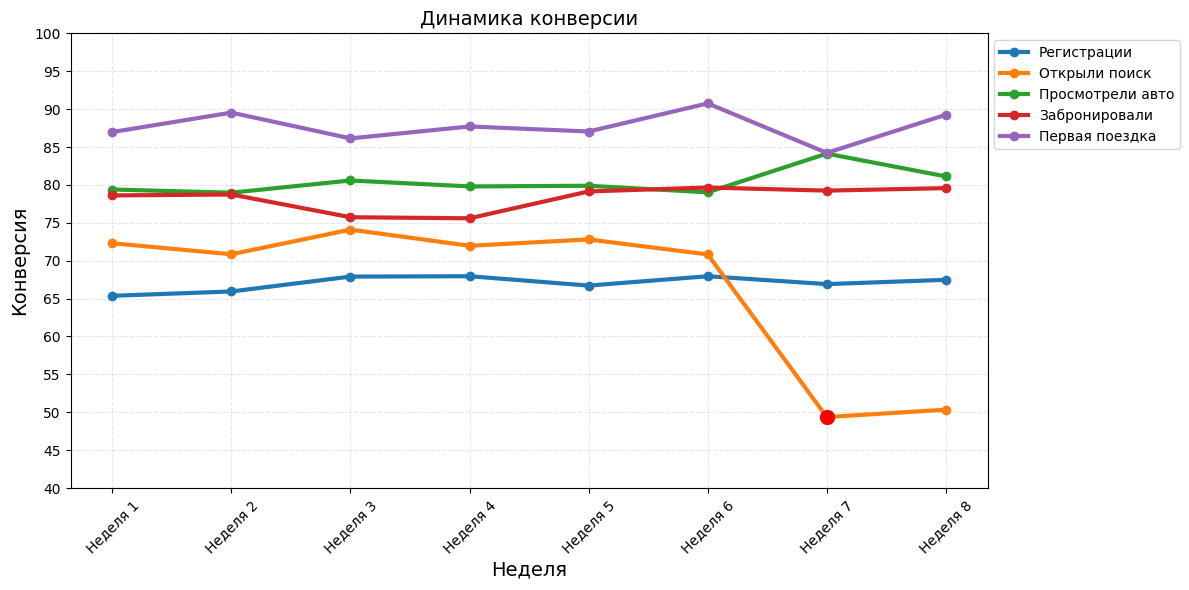

In [177]:
    plt.figure(figsize=(12, 6))
    plt.plot(data['week'], data['conv_reg'], label='Регистрации',marker='o', linewidth=3)
    plt.plot(data['week'], data['conv_search'], label='Открыли поиск',marker='o', linewidth=3)
    plt.plot(data['week'], data['conv_cars'], label='Просмотрели авто',marker='o',linewidth=3)
    plt.plot(data['week'], data['conv_booking'], label='Забронировали',marker='o', linewidth=3)
    plt.plot(data['week'], data['conv_trip'], label='Первая поездка',marker='o', linewidth=3)
    plt.plot(x, y, 'ro',markersize=10)
    plt.title('Динамика конверсии',fontsize=14)
    plt.xlabel('Неделя', fontsize=14)
    plt.ylabel('Конверсия', fontsize=14)
    plt.ylim(40, 100)           # границы от 50 до 100
    plt.yticks(range(40, 101, 5))  # 50,55,60,65,70,75,80,85,90,95,100
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
